In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow, RBackflow
from detnqs.vstate import MCState
from detnqs.sampler import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("single")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [2]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(16)]),
    basis="sto-6g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Orthonormalized Atomic Orbitals (OAOs)
C = lo.orth.orth_ao(mol, 'lowdin')
h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), mol.nao_nr())
h1e[abs(h1e) < 1e-6] = eri[abs(eri) < 1e-6] = 0.0
mo_coeff = np.linalg.solve(C, mf.mo_coeff)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_coeff[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_coeff[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

e_fci = -7.66652801326695

# solver = fci.direct_spin0.FCI(mol)
# e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
# s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

# print(f"SCF energy : {mf.e_tot:.12f}")
# print(f"FCI energy : {e_fci:.12f}")
# print(f"S^2  : {s2:.6f}")

In [3]:
model = RBackflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    proposal="ham",
    blur=0.5,
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

steps = 1000

E0602 17:58:09.744956   59379 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0602 17:58:09.753448   59242 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


-----------------------------------------------------------------------------------------------
 Step          Energy      |E-E0|        Var     Acc     ESS     N_u     N_f   alpha    SR cond
-----------------------------------------------------------------------------------------------
    0     -6.45193481    1.21e+00   4.64e-01   0.749   0.272    1024  117891    1.00   2.08e+04
   10     -6.74855089    9.18e-01   3.19e-01   0.565   0.722    1024  118921    1.79   2.20e+05
   20     -7.09319973    5.73e-01   2.30e-01   0.434   0.704    1023  119298    1.85   2.21e+05
   30     -7.30145597    3.65e-01   1.89e-01   0.329   0.666    1020  116791    1.86   5.30e+04
   40     -7.45316458    2.13e-01   1.47e-01   0.275   0.596    1013  112099    1.85   2.54e+04
   50     -7.53009033    1.36e-01   1.13e-01   0.230   0.565    1005  107613    1.84   3.56e+04
   60     -7.58646059    8.01e-02   7.55e-02   0.200   0.534     987  102794    1.81   5.94e+04
   70     -7.60852289    5.80e-02   6.67

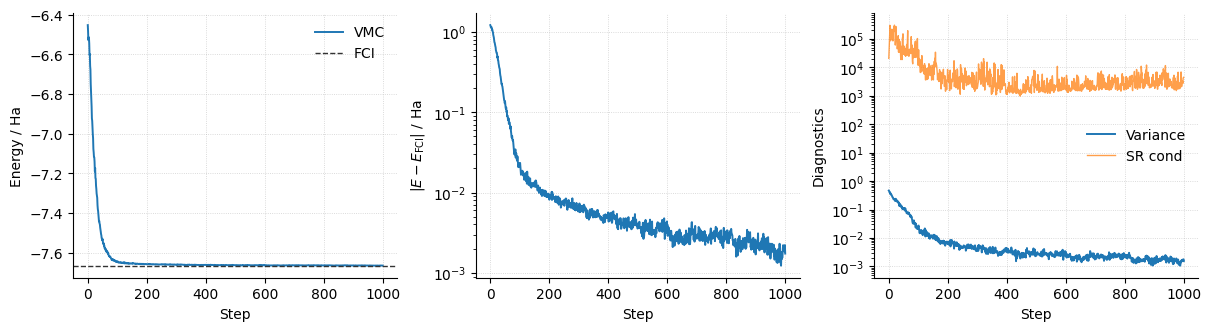

In [4]:
METRICS = {
    "step": ("Step", "5d"),
    "energy": ("Energy", "14.8f"),
    "error": ("|E-E0|", "10.2e"),
    "variance": ("Var", "9.2e"),
    "accept": ("Acc", "6.3f"),
    "ess_frac": ("ESS", "6.3f"),
    "n_unique": ("N_u", "6.0f"),
    "n_eval": ("N_f", "6.0f"),
    "alpha": ("alpha", "6.2f"),
    "sr_cond": ("SR cond", "9.2e"),
}

width = {k: int(fmt[:-1].split(".")[0]) for k, (_, fmt) in METRICS.items()}

header = "  ".join(f"{label:>{width[k]}}" for k, (label, _) in METRICS.items())
line = "-" * len(header)

print(line, header, line, sep="\n")

vmc = VMC.init(state, optimizer)
history = []
total_times = {}

for step in range(steps):
    stats = vmc.step()
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(dict(stats))

    for k, v in stats.items():
        if k.startswith("time_"):
            name = k.removeprefix("time_")
            total_times[name] = total_times.get(name, 0.0) + float(v)

    if step % 10 == 0 or step == steps - 1:
        row = "  ".join(
            f"{int(stats.get(k, 0)):{fmt}}"
            if fmt.endswith("d")
            else f"{float(stats.get(k, 0.0)):{fmt}}"
            for k, (_, fmt) in METRICS.items()
        )
        print(row)

print(line)

if total_times:
    items = [(k, v) for k, v in total_times.items() if k != "total"]
    items = sorted(items, key=lambda kv: kv[1], reverse=True)
    print("Time:", "  ".join(f"{k}={v:.2f}s" for k, v in items))
    print(line)

hist = {k: np.asarray([s.get(k, np.nan) for s in history]) for k in METRICS}
x = hist["step"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

axes[0].plot(x, hist["energy"], lw=1.4, label="VMC")
axes[0].axhline(e_fci, ls="--", lw=1.0, c="0.2", label="FCI")
axes[0].set(xlabel="Step", ylabel="Energy / Ha")
axes[0].legend(frameon=False)

axes[1].semilogy(x, np.maximum(hist["error"], 1e-16), lw=1.4)
axes[1].set(xlabel="Step", ylabel=r"$|E-E_\mathrm{FCI}|$ / Ha")

axes[2].semilogy(x, np.maximum(hist["variance"], 1e-16), lw=1.4, label="Variance")
if "sr_cond" in hist:
    axes[2].semilogy(x, hist["sr_cond"], lw=1.0, alpha=0.75, label="SR cond")
axes[2].set(xlabel="Step", ylabel="Diagnostics")
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(True, ls=":", lw=0.6, alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()